# all locs

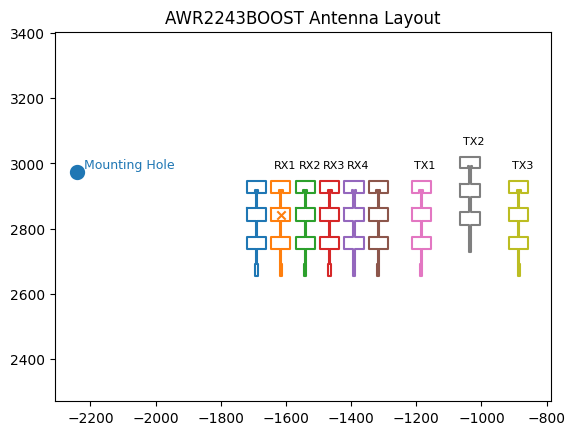

distance between antennas: 1.900 mm
from upper left hole to rx 1:
3.3501329999999996 15.837046242424242


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# data from the AWR2243BOOST schematics https://www.ti.com/lit/zip/SPRR415
# rx1's location
x = [2861.7, 2823.51, 2823.51, 2775.09, 2775.09, 2736.9, 2736.9, 2692.41, 2692.41, 2653.04, 2653.04, 2692.41, 2692.41, 
 2736.9, 2736.9, 2775.09, 2775.09, 2823.51, 2823.51, 2861.7, 2861.7, 2918.04, 2918.04, 2910.13, 2910.13, 2946.35, 2946.35,
 2910.13, 2910.13, 2918.04, 2918.04, 2861.7, 2861.7]

y = [1645.13, 1645.13, 1617.57, 1617.57, 1645.13, 1645.13, 1617.57, 1617.57, 1619.14, 1619.14, 1612.06, 1612.06, 
     1613.63, 1613.63, 1586.07, 1586.07, 1613.63, 1613.63, 1586.07, 1586.07, 1613.63, 1613.63, 1609.69, 1609.69,
     1586.07, 1586.07, 1645.13, 1645.13, 1621.5, 1621.5, 1617.57, 1617.57, 1645.13]

rx1_center_x = (x[18]+x[19])/2
rx1_center_y = np.mean(y)


# mil to mm
s = 0.0254

x_hole = 2974.5
y_hole = 2240

x_antenna = [0, 0, 0, 0, 0, 0, 0, 74.81, 0]
y_antenna = [74.80, 0, -74.81, -149.61, -224.41, -299.21, -430.90, -580.31, -729.92]

d_antenna = 74.81

# antenna labels: 1-4 = RX, 5-7 = TX
antenna_labels = {1: 'RX1', 2: 'RX2', 3: 'RX3', 4: 'RX4', 6: 'TX1', 7: 'TX2', 8: 'TX3'}

plt.figure()
plt.scatter(-y_hole, x_hole, lw=5)
plt.text(-y_hole + 20, x_hole + 10, 'Mounting Hole', fontsize=9, color='tab:blue')

for i, (offset_x, offset_y) in enumerate(zip(x_antenna, y_antenna)):
     plt.plot([-(yy + offset_y) for yy in y], [xx + offset_x for xx in x])
     if i in antenna_labels:
          cx = -(np.mean(y) + offset_y)
          cy = (x[18]+x[19])/2 + offset_x
          plt.text(cx-20, cy+150, antenna_labels[i], fontsize=8, va='center')

plt.scatter(-np.mean(y), (x[18]+x[19])/2, marker='x')
plt.axis('equal')
plt.title('AWR2243BOOST Antenna Layout')
plt.show()


print(f'distance between antennas: {d_antenna*s:.3f} mm')
print('from upper left hole to rx 1:')
print((x_hole - rx1_center_x)*s, (y_hole - rx1_center_y)*s)
